1. Server sends global model to clients
2. Clients train locally → return updated models
3. Server computes fairness gaps (Δ_k)
4. Server updates weights (w_k)
5. Server aggregates models using weights

In [63]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split

In [64]:
class Logger:
    def __init__(self, verbose=False):
        self.verbose = verbose

    def info(self, msg):
        print(msg)

    def debug(self, msg):
        if self.verbose:
            print(msg)

In [65]:
logger = Logger(verbose=True)


In [66]:
FAIRNESS_TYPE = "spd"

In [67]:
# =============================
# HYPERPARAMETERS
# =============================
LR = 1e-3
WEIGHT_DECAY = 0.0001
LOCAL_EPOCHS = 3
ROUNDS = 20
K = 5
BETA = 1

LAMBDA_BASE = 1.0
EPS = 1e-8
SEED = 20

In [68]:
def load_adult():
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

    cols = [
        "age","workclass","fnlwgt","education","education-num",
        "marital-status","occupation","relationship","race","sex",
        "capital-gain","capital-loss","hours-per-week","native-country","income"
    ]

    df = pd.read_csv(url, names=cols, na_values="?", skipinitialspace=True)
    df = df.dropna()

    df["income"] = (df["income"] == ">50K").astype(int)
    df["sex"] = (df["sex"] == "Male").astype(int)

    df = pd.get_dummies(df, drop_first=True)

    X = df.drop(columns=["income"])
    y = df["income"]
    A = df["sex"]

    X = (X - X.mean()) / X.std()

    return train_test_split(X.values, y.values, A.values, test_size=0.2, random_state=42)

In [69]:
# =============================
# DIRICHLET SPLIT (SAFE)
# =============================
def split_dirichlet(X, y, A, alpha):
    np.random.seed(SEED)

    while True:
        clients = [{"X": [], "y": [], "A": []} for _ in range(K)]

        for a in np.unique(A):
            idx = np.where(A == a)[0]
            np.random.shuffle(idx)

            proportions = np.random.dirichlet(alpha * np.ones(K))
            sizes = (proportions * len(idx)).astype(int)
            sizes[-1] += len(idx) - np.sum(sizes)

            start = 0
            for k in range(K):
                subset = idx[start:start+sizes[k]]
                clients[k]["X"].append(X[subset])
                clients[k]["y"].append(y[subset])
                clients[k]["A"].append(A[subset])
                start += sizes[k]

        for k in range(K):
            clients[k]["X"] = np.vstack(clients[k]["X"])
            clients[k]["y"] = np.concatenate(clients[k]["y"])
            clients[k]["A"] = np.concatenate(clients[k]["A"])

        MIN_SAMPLES = 100  # adjusting or cases where clients get 0 samples of a demographic

        if all(
            (len(c["y"]) >= MIN_SAMPLES) and
            (np.any(c["A"] == 0)) and
            (np.any(c["A"] == 1))
            for c in clients
        ):
            return clients


In [70]:
def build_distribution_table(X, y, A, alphas, K):
    results = {}

    for alpha in alphas:
        clients = split_dirichlet(X, y, A, alpha)

        A0_counts = []
        A1_counts = []

        for c in clients:
            A0_counts.append((c["A"] == 0).sum())
            A1_counts.append((c["A"] == 1).sum())


        results[alpha] = {
            "A=0": A0_counts,
            "A=1": A1_counts
        }

    # Build dataframe
    rows = []
    for k in range(K):
        row = {"Client ID": k}
        for alpha in alphas:
            row[f"α={alpha} (A=0)"] = results[alpha]["A=0"][k]
            row[f"α={alpha} (A=1)"] = results[alpha]["A=1"][k]
        rows.append(row)

    df = pd.DataFrame(rows)
    return df

In [71]:
alphas = [0.1,0.5,1,5,10]
X_train, X_test, y_train, y_test, A_train, A_test = load_adult()

df_check = build_distribution_table(X_train, y_train, A_train, alphas, K=5)
print(df_check)

   Client ID  α=0.1 (A=0)  α=0.1 (A=1)  α=0.5 (A=0)  α=0.5 (A=1)  α=1 (A=0)  \
0          0         7691          415         3269         2521       2659   
1          1            3         1490           53          638       2785   
2          2            1         2070         1029         6793        211   
3          3           80        11899         1460          481        845   
4          4           46          434         2010         5875       1321   

   α=1 (A=1)  α=5 (A=0)  α=5 (A=1)  α=10 (A=0)  α=10 (A=1)  
0       1767       1755       5034        1704        4461  
1       1598        979       2331        1151        2622  
2       3220       1197       2578        1314        2805  
3       3880       2340       4211        2086        3929  
4       5843       1550       2154        1566        2491  


##sanity check-dataset

In [72]:
# =============================
# MODEL
# =============================
class Model(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, 32),
            nn.ReLU(),
            nn.Linear(32, 1)  #this output represents the "log-odds" of the person being a high-earner.
        )

    def forward(self, x):
        return self.net(x)



In [73]:
# =============================
# METRICS
# =============================
def compute_metrics(model, X, y, A):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32))
        preds = (torch.sigmoid(logits).numpy() > 0.5).astype(int).flatten()

    acc = np.mean(preds == y)

    spd = np.mean(preds[A==1]) - np.mean(preds[A==0])

    mask1 = (A==1)&(y==1)
    mask0 = (A==0)&(y==1)

    tpr1 = np.sum((preds==1)&mask1) / max(np.sum(mask1),1)
    tpr0 = np.sum((preds==1)&mask0) / max(np.sum(mask0),1)

    eod = tpr0 - tpr1

    return acc, eod, spd



In [74]:
def compute_local_metrics(model, client):
    X = torch.tensor(client["X"], dtype=torch.float32)
    y = client["y"]
    A = client["A"]

    with torch.no_grad():
        logits = model(X)
        probs = torch.sigmoid(logits).numpy().flatten()
        preds = (probs > 0.5).astype(int)

    acc_k = np.mean(preds == y)

    # masks
    mask0 = (A == 0)
    mask1 = (A == 1)
    mask_y1 = (y == 1)

    # ----- SPD -----
    spd = np.mean(preds[mask0]) - np.mean(preds[mask1]) \
        if mask0.sum() > 0 and mask1.sum() > 0 else np.nan

    # ----- EOD -----
    mask0_y1 = mask0 & mask_y1
    mask1_y1 = mask1 & mask_y1

    if mask0_y1.sum() > 0 and mask1_y1.sum() > 0:
        tpr0 = np.mean(preds[mask0_y1])
        tpr1 = np.mean(preds[mask1_y1])
        eod = tpr0 - tpr1
    else:
        eod = np.nan

    return acc_k, spd, eod

$$\
m_{\text{global},k} =\frac{n_k}{n}
\left(
\frac{P(\hat{Y}=1|A=0,Y=1,C=k)\cdot P(A=0,Y=1|C=k)}{P(Y=1,A=0)}
-
\frac{P(\hat{Y}=1|A=1,Y=1,C=k)\cdot P(A=1,Y=1|C=k)}{P(Y=1,A=1)}
\right)
\
$$

In [75]:
# =============================
# CLIENT LOCAL METRICS
# =============================
def ClientLocalMetrics(client, model, S, total_n):
    X, y, A = client["X"], client["y"], client["A"]

    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32))
        preds = (torch.sigmoid(logits).numpy() > 0.5).astype(int).flatten()

    acc_k = np.mean(preds == y)
    n_k = len(y)



    if  FAIRNESS_TYPE == "eod":
        idx_y1 = (y==1)
        idx_a0 = (A==0)&idx_y1
        idx_a1 = (A==1)&idx_y1

        c0 = np.sum(idx_a0)
        c1 = np.sum(idx_a1)

        tpr0 = np.sum((preds==1)&idx_a0) / max(c0,1)
        tpr1 = np.sum((preds==1)&idx_a1) / max(c1,1)

        p0_ck = c0 / n_k if n_k > 0 else 0
        p1_ck = c1 / n_k if n_k > 0 else 0

        p0, p1 = S
        m_k = (n_k/total_n)*((tpr0*p0_ck)/max(p0,1e-8) - (tpr1*p1_ck)/max(p1,1e-8))

    elif FAIRNESS_TYPE == "spd":
        # SPD = difference in positive prediction rates (no conditioning on y=1)

        idx_a0_all = (A == 0)
        idx_a1_all = (A == 1)

        c0_all = np.sum(idx_a0_all)
        c1_all = np.sum(idx_a1_all)

        pr0 = np.sum((preds==1) & idx_a0_all) / max(c0_all, 1)
        pr1 = np.sum((preds==1) & idx_a1_all) / max(c1_all, 1)

        p0_ck_all = c0_all / n_k if n_k > 0 else 0
        p1_ck_all = c1_all / n_k if n_k > 0 else 0
        p0, p1 = S
        m_k = (n_k/total_n)*((pr0*p0_ck_all)/max(p0,1e-8) - (pr1*p1_ck_all)/max(p1,1e-8))

    else:
        raise ValueError("Unsupported fairness type")
    return np.array([(n_k/total_n)*acc_k, m_k]), m_k

Changed here

 $$
\bar{w}_k^{t} = \bar{w}_k^{t-1} - \beta \left( \Delta_k - \bar{\Delta} \right)
$$


In [76]:
# # =============================
# # CLIENT METRIC GAP
# # =============================
# def ClientMetricGap(client, model, m_k, F_global, total_n):
#     X, y = client["X"], client["y"]

#     with torch.no_grad():
#         logits = model(torch.tensor(X, dtype=torch.float32))
#         preds = (torch.sigmoid(logits).numpy() > 0.5).astype(int).flatten()

#     acc_k = np.mean(preds == y)
#     n_k = len(y)

#     if np.isnan(m_k) or np.isinf(m_k):
#         return abs((n_k/total_n)*acc_k - acc_k)
#     else:
#         return abs(F_global - F_k)

In [77]:
# =============================
# CLIENT METRIC GAP
# =============================
def ClientMetricGap(client, model, F_global):
    X, y, A = client["X"], client["y"], client["A"]

    with torch.no_grad():
        logits = model(torch.tensor(X, dtype=torch.float32))
        preds = (torch.sigmoid(logits).numpy() > 0.5).astype(int).flatten()

    # ---- Compute local fairness F_k (EOD) ----
    mask1 = (A == 1) & (y == 1)
    mask0 = (A == 0) & (y == 1)

    # Handle undefined case (no samples)
    if np.sum(mask1) == 0 or np.sum(mask0) == 0:
        # fallback to accuracy gap
        acc_k = np.mean(preds == y)
        return abs(acc_k)   # or abs(acc_k - global_acc) if you track it

    tpr1 = np.sum((preds == 1) & mask1) / np.sum(mask1)
    tpr0 = np.sum((preds == 1) & mask0) / np.sum(mask0)

    F_k = tpr0 - tpr1   #local fairness metric(EOD)

    # ---- Fairness gap ----
    delta_k = abs(F_k - F_global)

    return delta_k

In [78]:
# =============================
# ORIGINAL CLIENT UPDATE
# =============================
def ClientWeightedModelUpdate(client, global_model, w_bar_k, delta_k, delta_mean):
    model = Model(client["X"].shape[1])
    model.load_state_dict(global_model.state_dict())

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    loss_fn = nn.BCEWithLogitsLoss()

    X = torch.tensor(client["X"], dtype=torch.float32)
    y = torch.tensor(client["y"], dtype=torch.float32).view(-1,1)
    A = torch.tensor(client["A"], dtype=torch.float32)
    for _ in range(LOCAL_EPOCHS):

      optimizer.zero_grad()
      logits = model(X)
      loss_task = loss_fn(logits, y)
      # ---- fairness term ----
      probs = torch.sigmoid(logits).view(-1)
      y_flat = y.view(-1)
      A_flat = A.view(-1)

      mask0 = (A_flat == 0)
      mask1 = (A_flat == 1)

      if FAIRNESS_TYPE == "spd":
          if mask0.sum() > 0 and mask1.sum() > 0:
              mean0 = probs[mask0].mean()
              mean1 = probs[mask1].mean()
              loss_fair = (mean0 - mean1) ** 2
          else:
              loss_fair = torch.tensor(0.0, device=logits.device)

      elif FAIRNESS_TYPE == "eod":
          mask_y1 = (y_flat == 1)
          mask0_y1 = mask0 & mask_y1
          mask1_y1 = mask1 & mask_y1

          if mask0_y1.sum() > 0 and mask1_y1.sum() > 0:
              tpr0 = probs[mask0_y1].mean()
              tpr1 = probs[mask1_y1].mean()
              loss_fair = (tpr0 - tpr1) ** 2
          else:
              loss_fair = torch.tensor(0.0, device=logits.device)


      # constant lambda for baseline
      lambda_k = 0.5

      loss = loss_task + lambda_k * loss_fair

      # ---- optimize ----
      loss.backward()
      optimizer.step()

    with torch.no_grad():
        logits_eval = model(X)
        preds = (torch.sigmoid(logits_eval).numpy() > 0.5).astype(int).flatten()
    acc_k = np.mean(preds == client["y"])
    logger.debug(f"Loss={loss.item():.4f} | Acc={acc_k:.4f}")



    return model

In [79]:
# =============================
# MODIFIED CLIENT UPDATE
# =============================
def ClientWeightedModelUpdate_FairReg(client, global_model, w_bar_k, delta_k, delta_max, delta_mean):
    model = Model(client["X"].shape[1])
    model.load_state_dict(global_model.state_dict())

    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    bce_loss = nn.BCEWithLogitsLoss()

    X = torch.tensor(client["X"], dtype=torch.float32)
    y = torch.tensor(client["y"], dtype=torch.float32).view(-1,1)
    A = torch.tensor(client["A"], dtype=torch.float32)
    #adaptive lambda
    lambda_k = LAMBDA_BASE * (delta_k / (delta_mean + EPS))
    for _ in range(LOCAL_EPOCHS):

      optimizer.zero_grad()
      logits = model(X)
      probs = torch.sigmoid(logits)
      loss_task = bce_loss(logits, y)

      y_flat = y.squeeze()
      A_flat = A.squeeze()
      mask0 = (A_flat == 0)
      mask1 = (A_flat == 1)
      # =============================
      # FAIRNESS SWITCH
      # =============================
      if FAIRNESS_TYPE == "spd":

          if mask0.any() and mask1.any():
              mean0 = probs[mask0].mean()
              mean1 = probs[mask1].mean()
              loss_fair = (mean0 - mean1) ** 2
          else:
              loss_fair = torch.tensor(0.0, device=logits.device)

      elif FAIRNESS_TYPE == "eod":

          mask_y1 = (y_flat == 1)
          mask0_y1 = mask0 & mask_y1
          mask1_y1 = mask1 & mask_y1

          if mask0_y1.any() and mask1_y1.any():
              tpr0 = probs[mask0_y1].mean()
              tpr1 = probs[mask1_y1].mean()
              loss_fair = (tpr0 - tpr1) ** 2
          else:
              loss_fair = torch.tensor(0.0, device=logits.device)
      else:
              raise ValueError("Invalid FAIRNESS_TYPE")


      loss = loss_task + lambda_k * loss_fair
      loss.backward()
      optimizer.step()

   # logging
    with torch.no_grad():
        preds = (torch.sigmoid(logits).numpy() > 0.5).astype(int).flatten()

    acc_k = np.mean(preds == client["y"])
    logger.debug(f"    Loss={loss.item():.4f} | Task={loss_task.item():.4f} | "
    f"Fair={loss_fair.item():.4f} | lambda_k={lambda_k:.4f} | Acc={acc_k:.4f}")
    # w_bar_k = w_bar_k - BETA * (delta_k - delta_mean)

    return model


In [80]:
# =============================
# AGGREGATION
# =============================
def aggregate(models, weights):
    new_model = Model(models[0].net[0].in_features)
    state_dict = new_model.state_dict()

    for key in state_dict:
        state_dict[key] = sum(weights[k]*models[k].state_dict()[key] for k in range(len(models)))

    new_model.load_state_dict(state_dict)
    return new_model


In [81]:
# =============================
# FAIRFED (ORIGINAL)
# =============================
def fairfed(clients, X_test, y_test, A_test):
    total_n = sum(len(c["y"]) for c in clients)
    model = Model(clients[0]["X"].shape[1])

    total_y1_a0 = sum(np.sum((c["A"]==0)&(c["y"]==1)) for c in clients)
    total_y1_a1 = sum(np.sum((c["A"]==1)&(c["y"]==1)) for c in clients)

    S = [total_y1_a0/total_n, total_y1_a1/total_n]

    w_bar = np.array([len(c["y"])/total_n for c in clients])
    history = []
    for rnd in range(ROUNDS):
        logger.info(f"\n[FairFed] Round {rnd+1}")


        payloads, m_vals = [], []

        for c in clients:
            p, m = ClientLocalMetrics(c, model, S, total_n)
            payloads.append(p)
            m_vals.append(m)

        payloads = np.array(payloads)
        F_global = np.sum(payloads[:,1])
        logger.debug(f"  F_global = {F_global:.4f}")
        logger.debug(f"  m_k vals = {[round(float(m),4) for m in m_vals]}")

        deltas = [
            ClientMetricGap(clients[k], model, F_global)
            for k in range(K)
        ]
        delta_mean = np.mean(deltas)
        logger.debug(f"  Deltas   = {[round(float(d),4) for d in deltas]}")
        logger.debug(f"  Delta mean = {delta_mean:.4f}")
        new_w_bar = []
        local_models = []

        for k in range(K):
            lm = ClientWeightedModelUpdate(
                clients[k], model, w_bar[k], deltas[k], delta_mean
            )
            local_models.append(lm)
            # SERVER updates weight (FairFed rule)
            w_new = w_bar[k] - BETA * (deltas[k] - delta_mean)
            new_w_bar.append(w_new)
            logger.debug(f"  [Client {k}] loss trained | w_bar_new={w_new:.4f}")

        w_bar = np.array(new_w_bar)
        # clipping
        w_bar = np.maximum(w_bar, 0)
        # Normalize
        if np.sum(w_bar) == 0:
            w = np.ones(K) / K
        else:
            w = w_bar / np.sum(w_bar)
        logger.debug(f"  Weights  = {[round(float(x),4) for x in w]}")
        logger.debug(f"  w_bar    = {[round(float(x),4) for x in w_bar]}")
        #aggregate
        model = aggregate(local_models, w)
        # =============================
        # LOCAL FAIRNESS METRICS
        # =============================
        local_accs = []
        local_spds = []
        local_eods = []

        for c in clients:
            acc_k, spd_k, eod_k = compute_local_metrics(model, c)
            local_accs.append(acc_k)
            local_spds.append(spd_k)
            local_eods.append(eod_k)

        acc, eod, spd = compute_metrics(model, X_test, y_test, A_test)
        round_m_k = [float(m) for m in m_vals]
        history.append({
            'round': rnd+1,
            'acc': acc,
            'eod': eod,
            'spd': spd,
            'local_accs': local_accs,   # ← full list
            'local_spds': local_spds,   # ← full list
            'local_eods': local_eods,   # ← full list
        })
        logger.info(f"[Round {rnd+1}] Acc={acc:.4f} | EOD={eod:.4f} | SPD={spd:.4f}")
        final_metrics = compute_metrics(model, X_test, y_test, A_test)
    return final_metrics,history

In [82]:
import matplotlib.pyplot as plt

def plot_training_results(history_orig, history_mod):
    rounds = [h['round'] for h in history_orig]
    fairness_type = FAIRNESS_TYPE
    fig, (ax1, axF) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot 1: Accuracy over Rounds
    ax1.plot(rounds, [h['acc'] for h in history_orig], label='FairFed (Original)', marker='o')
    ax1.plot(rounds, [h['acc'] for h in history_mod], label='FairFed+ (Modified)', marker='s')
    ax1.set_title("Global Model Accuracy vs. Communication Rounds")
    ax1.set_xlabel("Round")
    ax1.set_ylabel("Accuracy")
    ax1.grid(True)
    ax1.legend()

    # ----------------------
    # Plot 2: Fairness (based on global fairness_type)
    # ----------------------
    if fairness_type == "eod":
        axF.plot(rounds, [h['eod'] for h in history_orig], label='FairFed', marker='o', color='red')
        axF.plot(rounds, [h['eod'] for h in history_mod], label='FairFed+', marker='s', color='green')
        axF.set_title("EOD vs Rounds")
        axF.set_ylabel("EOD (→ 0 is fair)")

    elif fairness_type == "spd":
        axF.plot(rounds, [h['spd'] for h in history_orig], label='FairFed', marker='o', color='red')
        axF.plot(rounds, [h['spd'] for h in history_mod], label='FairFed+', marker='s', color='green')
        axF.set_title("SPD vs Rounds")
        axF.set_ylabel("SPD (→ 0 is fair)")

    # Common styling
    axF.axhline(y=0, color='black', linestyle='--', linewidth=2, label='Fairness Target (0)')
    axF.set_xlabel("Round")
    axF.grid(True)
    axF.legend()

    # Ensure 0 visible
    ymin, ymax = axF.get_ylim()
    axF.set_ylim(min(ymin, -0.1), max(ymax, 0.1))

    plt.tight_layout()
    plt.show()

In [83]:
def plot_alpha_comparison(results_df):

    # ----------------------
    # Accuracy
    # ----------------------
    results_df.plot(
        x='alpha',
        y=['Acc(FairFed)', 'Acc(New)'],
        kind='bar',
        figsize=(10, 5)
    )
    plt.title("Accuracy Comparison across Dirichlet Alpha")
    plt.ylabel("Accuracy")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

    # ----------------------
    # Fairness (switch)
    # ----------------------
    if FAIRNESS_TYPE == "eod":
        y_cols = ['EOD(FairFed)', 'EOD(New)']
        title = "Fairness Error (EOD) across Dirichlet Alpha"
        ylabel = "EOD (→ 0 is fair)"

    elif FAIRNESS_TYPE == "spd":
        y_cols = ['SPD(FairFed)', 'SPD(New)']
        title = "Fairness Error (SPD) across Dirichlet Alpha"
        ylabel = "SPD (→ 0 is fair)"

    else:
        raise ValueError("fairness_type must be 'eod' or 'spd'")

    results_df.plot(
        x='alpha',
        y=y_cols,
        kind='bar',
        figsize=(10, 5),
        color=['red', 'blue']
    )


    plt.axhline(y=0, color='black', linestyle='--', linewidth=2)

    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.show()

In [84]:
# =============================
# FAIRFED MODIFIED
# =============================
def fairfed_modified(clients, X_test, y_test, A_test):
    total_n = sum(len(c["y"]) for c in clients)
    model = Model(clients[0]["X"].shape[1])

    total_y1_a0 = sum(np.sum((c["A"]==0)&(c["y"]==1)) for c in clients)
    total_y1_a1 = sum(np.sum((c["A"]==1)&(c["y"]==1)) for c in clients)

    S = [total_y1_a0/total_n, total_y1_a1/total_n]

    w_bar = np.array([len(c["y"])/total_n for c in clients])
    history = []
    for rnd in range(ROUNDS):

        payloads, m_vals = [], []

        for c in clients:
            p, m = ClientLocalMetrics(c, model, S, total_n)
            payloads.append(p)
            m_vals.append(m)

        payloads = np.array(payloads)
        F_global = np.sum(payloads[:,1])

        deltas = [
            ClientMetricGap(clients[k], model, F_global)
            for k in range(K)
        ]

        delta_mean = np.mean(deltas)
        delta_max = max(deltas)

        new_w_bar = []
        local_models = []

        for k in range(K):
            lm = ClientWeightedModelUpdate_FairReg(
                clients[k], model, w_bar[k],
                deltas[k], delta_max, delta_mean
            )
            local_models.append(lm)
            w_new = w_bar[k] - BETA * (deltas[k] - delta_mean)
            new_w_bar.append(w_new)
            logger.debug(f"  [Client {k}] loss trained | w_bar_new={w_new:.4f}")

        w_bar = np.array(new_w_bar)

        w_bar = np.maximum(w_bar, 0)

        if np.sum(w_bar) == 0:
            w = np.ones(K) / K
        else:
            w = w_bar / np.sum(w_bar)

        model = aggregate(local_models, w)
        # =============================
        # LOCAL FAIRNESS METRICS
        # =============================
        local_accs = []
        local_spds = []
        local_eods = []

        for c in clients:
            acc_k, spd_k, eod_k = compute_local_metrics(model, c)
            local_accs.append(acc_k)
            local_spds.append(spd_k)
            local_eods.append(eod_k)

        acc, eod, spd = compute_metrics(model, X_test, y_test, A_test)
        round_m_k = [float(m) for m in m_vals]
        history.append({
            'round': rnd+1,
            'acc': acc,
            'eod': eod,
            'spd': spd,
            'local_accs': local_accs,   # ← full list
            'local_spds': local_spds,   # ← full list
            'local_eods': local_eods,   # ← full list
        })

        print(f"  >> Test Acc={acc:.4f} | EOD={eod:.4f} | SPD={spd:.4f}")
    return compute_metrics(model, X_test, y_test, A_test),history

In [85]:
def summarize(local_vals):
    local_vals = np.array(local_vals)
    return (
        np.mean(np.abs(local_vals)),   # mean |EOD|
        np.max(np.abs(local_vals)),    # worst
        np.sqrt(np.mean(local_vals**2))             # rms
    )

In [86]:
# =============================
# RUN COMPARISON TABLE
# =============================
def run_comparison():
    X_train, X_test, y_train, y_test, A_train, A_test = load_adult()

    alphas = [0.1,0.5,1,5,10]
    rows = []

    for alpha in alphas:
        print(f"\n{'#'*60}")
        print(f"ALPHA = {alpha}")
        print(f"{'#'*60}")

        clients = split_dirichlet(X_train, y_train, A_train, alpha)

        print("\n--- Running FairFed (Original) ---")
        res1, hist1 = fairfed(clients, X_test, y_test, A_test)
        acc1, eod1, spd1 = res1
        logger.info(f"\nFairFed Final test : Acc={acc1:.4f} | EOD={eod1:.4f} | SPD={spd1:.4f}")

        print("\n--- Running FairFed+ (Modified) ---")
        res2, hist2 = fairfed_modified(clients, X_test, y_test, A_test)
        acc2, eod2, spd2 = res2
        logger.info(f"\nFairFed+ Finaltest: Acc={acc2:.4f} | EOD={eod2:.4f} | SPD={spd2:.4f}")

        # 3. CALL THE PLOTS HERE
        print(f"\nGenerating plots for Alpha(training)= {alpha}...")
        plot_training_results(hist1, hist2)

        # print(f"\nAnalyzing Client Fairness for Alpha = {alpha}...")
        # plot_client_fairness(hist1,title=f"Client m_k Trends (FairFed) - Alpha {alpha}")
        # plot_client_fairness(hist2, title=f"Client m_k Trends (FairFed+ Modified) - Alpha {alpha}")

        plot_per_client_fairness(hist1,  'FairFed - Client fairness')
        plot_per_client_fairness(hist2,  'FairFed+ -  Client fairness')
        final_local_eods_1 = hist1[-1]['local_eods']
        final_local_spds_1 = hist1[-1]['local_spds']

        final_local_eods_2 = hist2[-1]['local_eods']
        final_local_spds_2 = hist2[-1]['local_spds']


        mean_eod1, worst_eod1, std_eod1 = summarize(final_local_eods_1)
        mean_eod2, worst_eod2, std_eod2 = summarize(final_local_eods_2)
        rows.append([
            alpha,
            acc1, eod1, spd1,
            acc2, eod2, spd2,
            mean_eod1, worst_eod1, std_eod1,
            mean_eod2, worst_eod2, std_eod2])

    results_df = pd.DataFrame(rows, columns=["alpha", "Acc(FairFed)", "EOD(FairFed)", "SPD(FairFed)", "Acc(New)", "EOD(New)", "SPD(New)","Mean|EOD|_Local(FairFed)", "Worst|EOD|_FairFed", "Std_EOD_FairFed","Mean|EOD|_Local(New)", "Worst|EOD|_New", "Std_EOD_New"])

    # 4. CALL THE ALPHA COMPARISON PLOT
    plot_alpha_comparison(results_df)




    return results_df


In [87]:
def plot_client_fairness(history, title="Client Fairness Contributions (m_k)"):
    rounds = [h['round'] for h in history]
    # Extract m_k for each client (transpose the list of lists)
    mks = np.array([h['client_mks'] for h in history])
    num_clients = mks.shape[1]

    plt.figure(figsize=(10, 6))
    for i in range(num_clients):
        plt.plot(rounds, mks[:, i], label=f'Client {i}', marker='.')

    plt.axhline(y=0, color='black', linestyle='--', alpha=0.5) # The "Fair" baseline
    plt.title(title)
    plt.xlabel("Round")
    plt.ylabel("Local Fairness Metric (m_k)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, which='both', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [88]:
import matplotlib.pyplot as plt

def plot_combined_client_fairness(history_orig, history_mod, title_prefix='Client Fairness Comparison'):
    rounds = [h['round'] for h in history_orig]
    fairness_type = FAIRNESS_TYPE

    if fairness_type == "eod":
        metric = "local_eods"
        ylabel = "EOD (Absolute Value)"
    elif fairness_type == "spd":
        metric = "local_spds"
        ylabel = "SPD (Absolute Value)"
    else:
        raise ValueError("fairness_type must be 'eod' or 'spd'")

    K = len(history_orig[0][metric]) # Number of clients

    # Determine grid size for subplots
    # Aim for roughly square layout, e.g., if K=5, use 2x3 grid
    ncols = int(np.ceil(np.sqrt(K)))
    nrows = int(np.ceil(K / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows), squeeze=False)
    axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

    fig.suptitle(f'{title_prefix} ({fairness_type.upper()})', fontsize=16)

    for k in range(K):
        ax = axes[k]
        # Plot FairFed (original) data
        values_orig = [np.abs(h[metric][k]) for h in history_orig]
        ax.plot(rounds, values_orig, label='FairFed', marker='.', linestyle='-')

        # Plot FairFed+ (modified) data
        values_mod = [np.abs(h[metric][k]) for h in history_mod]
        ax.plot(rounds, values_mod, label='FairFed+', marker='x', linestyle='--')

        ax.axhline(y=0, color='black', linestyle=':', linewidth=1, label='Fairness Target (0)')
        ax.set_title(f'Client {k}')
        ax.set_xlabel('Round')
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle='--', alpha=0.5)
        ax.legend()

        # Adjust y-axis limits to always show 0 and prevent excessively large ranges
        ymin, ymax = ax.get_ylim()
        ax.set_ylim(min(ymin, -0.05), max(ymax, 0.05)) # Ensure 0 is visible and some buffer

    # Hide any unused subplots
    for i in range(K, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make space for suptitle
    plt.show()

In [89]:
def plot_fairness_variance(history1, history2):
    rounds = [h['round'] for h in history1]

    var1 = [np.std(h['local_eods']) for h in history1]
    var2 = [np.std(h['local_eods']) for h in history2]

    plt.plot(rounds, var1, label='FairFed', marker='o')
    plt.plot(rounds, var2, label='FairFed+', marker='s')

    plt.title("Fairness Variance Across Clients")
    plt.xlabel("Round")
    plt.ylabel("Std of EOD")
    plt.legend()
    plt.grid()
    plt.show()

In [90]:
def generate_client_summary_table(history_orig, history_mod):
    # Get the last round's metrics for FairFed (original)
    last_round_orig = history_orig[-1]
    local_accs_orig = last_round_orig['local_accs']
    local_eods_orig = last_round_orig['local_eods']
    local_spds_orig = last_round_orig['local_spds']

    # Get the last round's metrics for FairFed+ (modified)
    last_round_mod = history_mod[-1]
    local_accs_mod = last_round_mod['local_accs']
    local_eods_mod = last_round_mod['local_eods']
    local_spds_mod = last_round_mod['local_spds']

    num_clients = len(local_accs_orig)
    rows = []

    for k in range(num_clients):
        row = {
            'Client ID': k,
            'Acc (FairFed)': local_accs_orig[k],
            'EOD (FairFed)': local_eods_orig[k],
            'SPD (FairFed)': local_spds_orig[k],
            'Acc (FairFed+)': local_accs_mod[k],
            'EOD (FairFed+)': local_eods_mod[k],
            'SPD (FairFed+)': local_spds_mod[k]
        }
        rows.append(row)

    df_summary = pd.DataFrame(rows)
    return df_summary

Accuracy vs variance tradeoff

In [91]:
def plot_tradeoff(results_df):
    plt.scatter(results_df["Acc(FairFed)"], abs(results_df["EOD(FairFed)"]), label="FairFed")
    plt.scatter(results_df["Acc(New)"], abs(results_df["EOD(New)"]), label="FairFed+")

    plt.xlabel("Accuracy")
    plt.ylabel(" EOD")
    plt.title("Fairness–Accuracy Trade-off")
    plt.legend()
    plt.grid()
    plt.show()

In [92]:
import matplotlib.pyplot as plt

# =============================
# RUN COMPARISON TABLE
# =============================
def run_comparison():
    X_train, X_test, y_train, y_test, A_train, A_test = load_adult()

    alphas = [0.1,0.5,1,5,10]
    rows = []
    all_client_summaries = {}

    for alpha in alphas:
        print(f"\n{'#'*60}")
        print(f"ALPHA = {alpha}")
        print(f"{'#'*60}")

        clients = split_dirichlet(X_train, y_train, A_train, alpha)

        print("\n--- Running FairFed (Original) ---")
        res1, hist1 = fairfed(clients, X_test, y_test, A_test)
        acc1, eod1, spd1 = res1
        logger.info(f"\nFairFed Final test : Acc={acc1:.4f} | EOD={eod1:.4f} | SPD={spd1:.4f}")

        print("\n--- Running FairFed+ (Modified) ---")
        res2, hist2 = fairfed_modified(clients, X_test, y_test, A_test)
        acc2, eod2, spd2 = res2
        logger.info(f"\nFairFed+ Finaltest: Acc={acc2:.4f} | EOD={eod2:.4f} | SPD={spd2:.4f}")

        # 3. CALL THE PLOTS HERE
        print(f"\nGenerating plots for Alpha(training)= {alpha}...")
        plot_training_results(hist1, hist2)

        # Call the new combined client fairness plot
        plot_combined_client_fairness(hist1, hist2, title_prefix=f'Client Fairness Comparison for Alpha {alpha}')

        # Generate and store client summary table for this alpha
        client_summary_df = generate_client_summary_table(hist1, hist2)
        all_client_summaries[alpha] = client_summary_df

        rows.append([
            alpha,
            acc1, eod1, spd1,
            acc2, eod2, spd2
        ])

    results_df = pd.DataFrame(rows, columns=["alpha", "Acc(FairFed)", "EOD(FairFed)", "SPD(FairFed)", "Acc(New)", "EOD(New)", "SPD(New)"])

    # 4. CALL THE ALPHA COMPARISON PLOT
    plot_alpha_comparison(results_df)

    # Print all client summary tables
    for alpha, df in all_client_summaries.items():
        print(f"\n--- Client Summary Table for Alpha = {alpha} ---")
        print(df.to_string(index=False))

    # Print the requested heading before the global comparison table, now correctly placed
    print("\nGlobal Model Accuracy and Fairness Comparison (FairFed vs FairFed+)")
    # Print the final results_df internally to ensure order
    print(results_df.to_string(index=False))

    return results_df



############################################################
ALPHA = 0.1
############################################################

--- Running FairFed (Original) ---

[FairFed] Round 1
  F_global = 3.0599
  m_k vals = [3.9329, -0.0877, -0.1253, -0.6555, -0.0045]
  Deltas   = [2.9132, 0.5104, 0.492, 2.7506, 3.298]
  Delta mean = 1.9928
Loss=0.6650 | Acc=0.6747
  [Client 0] loss trained | w_bar_new=-0.5844
Loss=0.6787 | Acc=0.5934
  [Client 1] loss trained | w_bar_new=1.5443
Loss=0.6845 | Acc=0.5809
  [Client 2] loss trained | w_bar_new=1.5866
Loss=0.6803 | Acc=0.5937
  [Client 3] loss trained | w_bar_new=-0.2613
Loss=0.6701 | Acc=0.6167
  [Client 4] loss trained | w_bar_new=-1.2853
  Weights  = [0.0, 0.4932, 0.5068, 0.0, 0.0]
  w_bar    = [0.0, 1.5443, 1.5866, 0.0, 0.0]
[Round 1] Acc=0.5972 | EOD=0.1763 | SPD=-0.1578

[FairFed] Round 2
  F_global = 2.4295
  m_k vals = [3.0087, -0.0602, -0.08, -0.4395, 0.0005]
  Deltas   = [2.253, 0.5934, 0.5799, 2.1011, 2.62]
  Delta mean = 1.6295


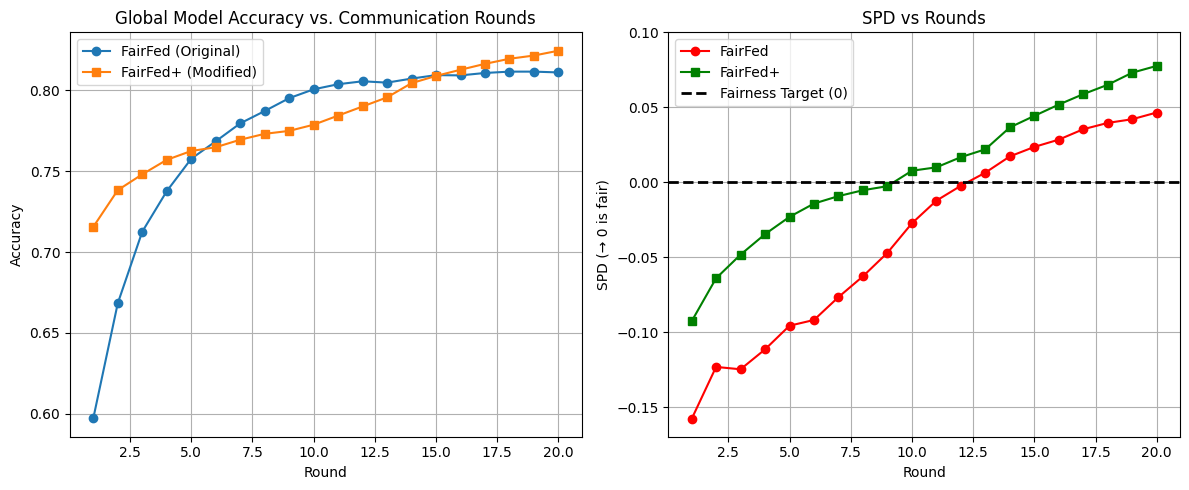

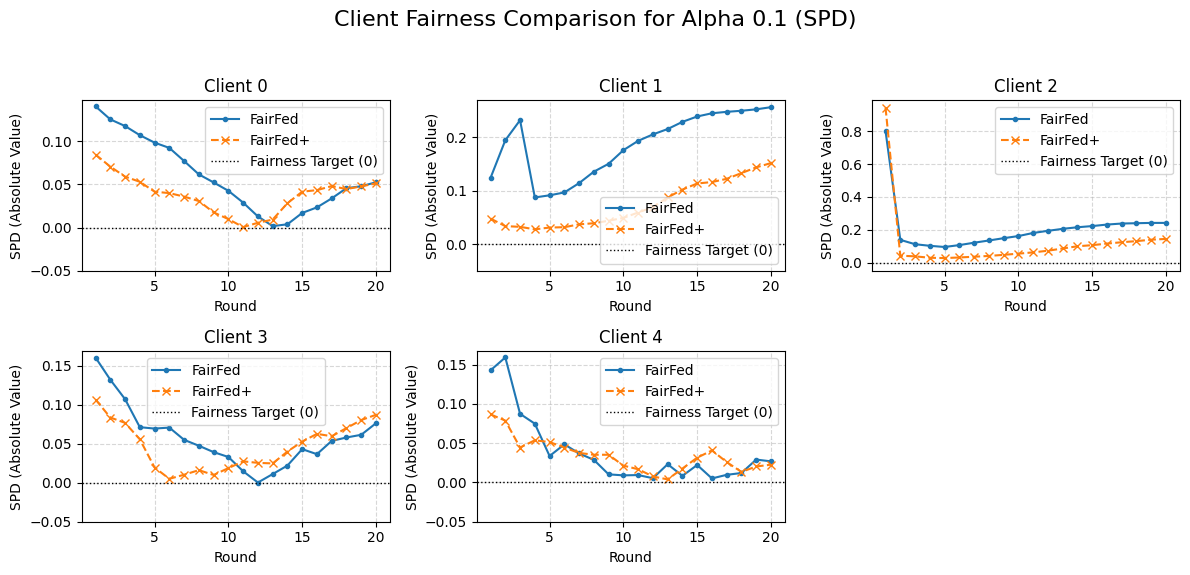


############################################################
ALPHA = 0.5
############################################################

--- Running FairFed (Original) ---

[FairFed] Round 1
  F_global = 4.6868
  m_k vals = [2.3233, -0.0103, 0.2099, 1.0898, 1.0741]
  Deltas   = [4.5116, 5.1531, 4.5087, 4.516, 4.5529]
  Delta mean = 4.6485
Loss=0.7025 | Acc=0.5710
  [Client 0] loss trained | w_bar_new=0.3768
Loss=0.6880 | Acc=0.6136
  [Client 1] loss trained | w_bar_new=-0.4760
Loss=0.6886 | Acc=0.6212
  [Client 2] loss trained | w_bar_new=0.4640
Loss=0.7050 | Acc=0.5688
  [Client 3] loss trained | w_bar_new=0.2129
Loss=0.6912 | Acc=0.6145
  [Client 4] loss trained | w_bar_new=0.4224
  Weights  = [0.2553, 0.0, 0.3143, 0.1443, 0.2861]
  w_bar    = [0.3768, 0.0, 0.464, 0.2129, 0.4224]
[Round 1] Acc=0.5840 | EOD=0.1611 | SPD=-0.1646

[FairFed] Round 2
  F_global = 3.4323
  m_k vals = [1.7615, -0.0067, 0.0713, 0.8558, 0.7504]
  Deltas   = [3.3054, 3.9246, 3.2762, 3.287, 3.3172]
  Delta mean 

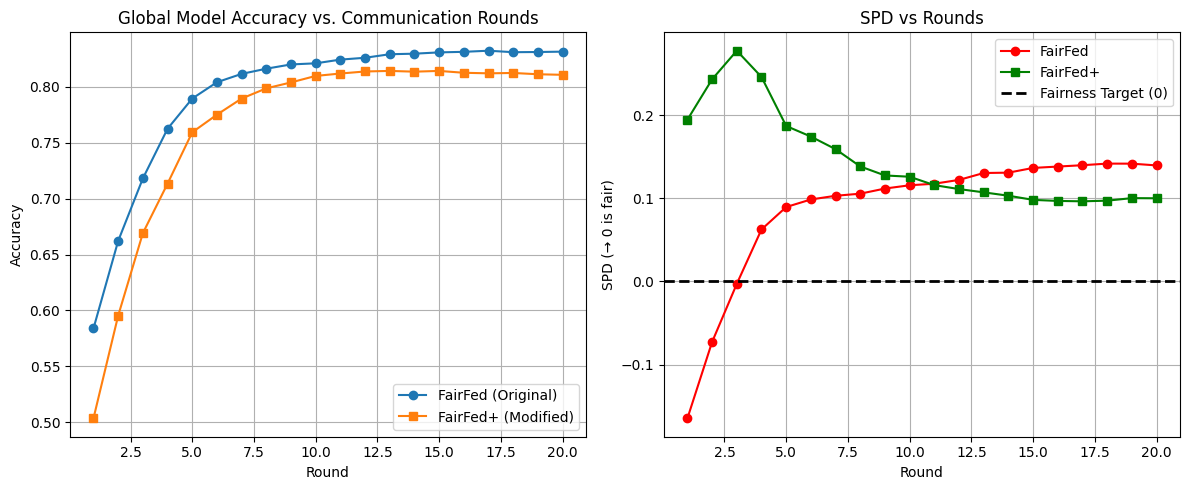

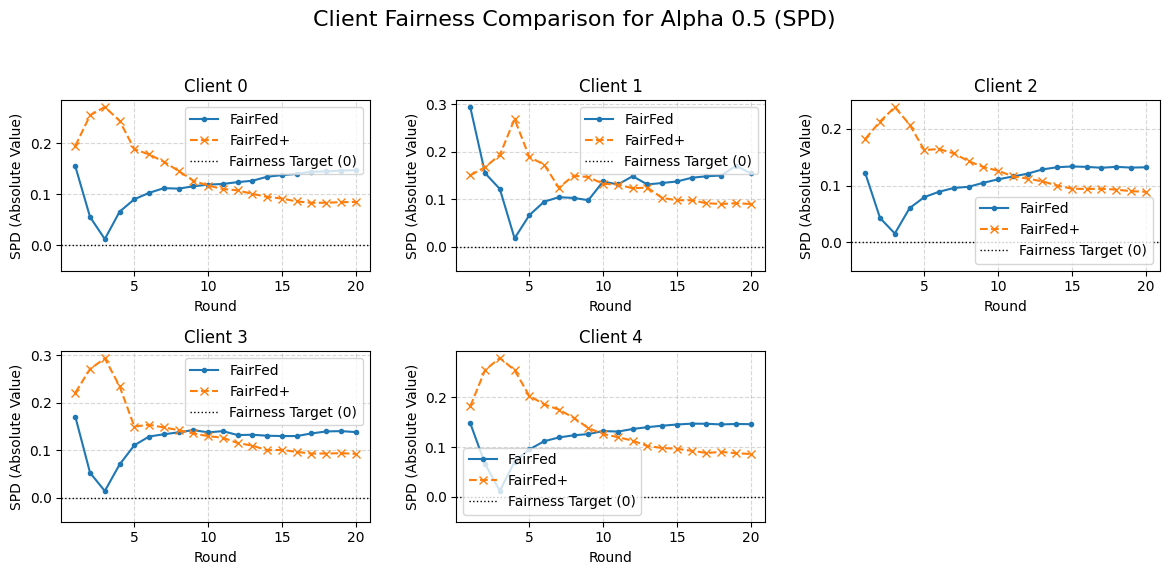


############################################################
ALPHA = 1
############################################################

--- Running FairFed (Original) ---

[FairFed] Round 1
  F_global = 0.8656
  m_k vals = [0.6611, 0.7719, -0.2796, -0.1228, -0.1649]
  Deltas   = [1.2121, 1.2302, 1.2083, 1.2055, 1.22]
  Delta mean = 1.2152
Loss=0.6687 | Acc=0.7058
  [Client 0] loss trained | w_bar_new=0.1866
Loss=0.6707 | Acc=0.6904
  [Client 1] loss trained | w_bar_new=0.1666
Loss=0.6798 | Acc=0.6217
  [Client 2] loss trained | w_bar_new=0.1491
Loss=0.6777 | Acc=0.6364
  [Client 3] loss trained | w_bar_new=0.2055
Loss=0.6804 | Acc=0.6205
  [Client 4] loss trained | w_bar_new=0.2921
  Weights  = [0.1866, 0.1666, 0.1491, 0.2055, 0.2921]
  w_bar    = [0.1866, 0.1666, 0.1491, 0.2055, 0.2921]
[Round 1] Acc=0.6522 | EOD=-0.3685 | SPD=0.2418

[FairFed] Round 2
  F_global = 0.3044
  m_k vals = [0.4056, 0.5039, -0.2316, -0.1563, -0.2172]
  Deltas   = [0.66, 0.6546, 0.6544, 0.6525, 0.6418]
  Delta

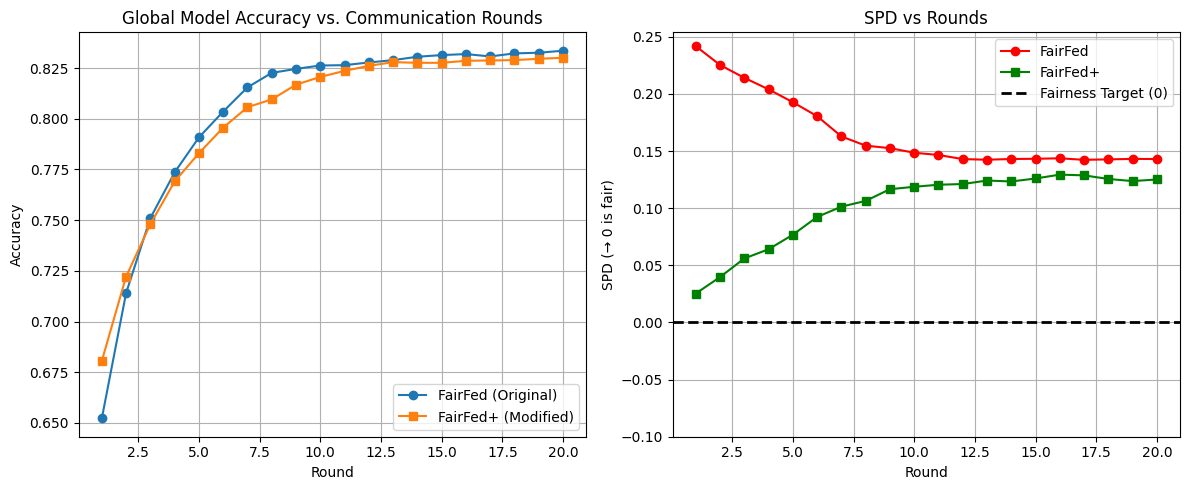

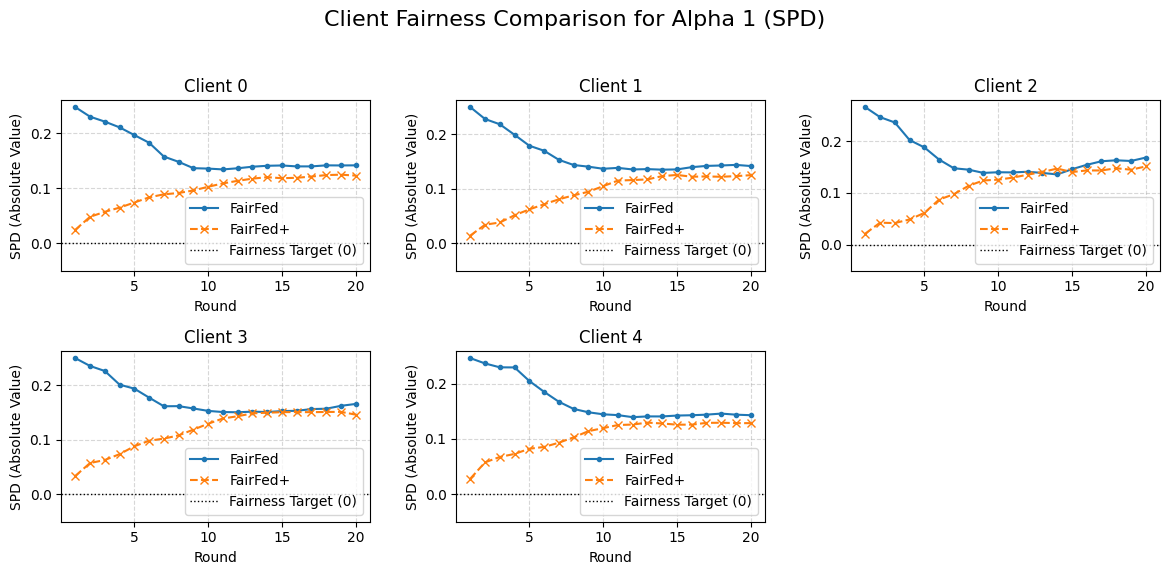


############################################################
ALPHA = 5
############################################################

--- Running FairFed (Original) ---

[FairFed] Round 1
  F_global = 3.8431
  m_k vals = [0.6287, 0.4319, 0.587, 1.2648, 0.9306]
  Deltas   = [3.7275, 3.7371, 3.6699, 3.7204, 3.7123]
  Delta mean = 3.7134
Loss=0.6948 | Acc=0.5384
  [Client 0] loss trained | w_bar_new=0.2673
Loss=0.6922 | Acc=0.5520
  [Client 1] loss trained | w_bar_new=0.1135
Loss=0.6922 | Acc=0.5566
  [Client 2] loss trained | w_bar_new=0.2000
Loss=0.6933 | Acc=0.5524
  [Client 3] loss trained | w_bar_new=0.2646
Loss=0.6942 | Acc=0.5483
  [Client 4] loss trained | w_bar_new=0.1547
  Weights  = [0.2673, 0.1135, 0.2, 0.2646, 0.1547]
  w_bar    = [0.2673, 0.1135, 0.2, 0.2646, 0.1547]
[Round 1] Acc=0.5579 | EOD=0.1517 | SPD=0.1142

[FairFed] Round 2
  F_global = 2.4411
  m_k vals = [0.321, 0.2879, 0.3776, 0.7992, 0.6553]
  Deltas   = [2.3322, 2.3076, 2.2714, 2.2998, 2.2669]
  Delta mean = 2.2

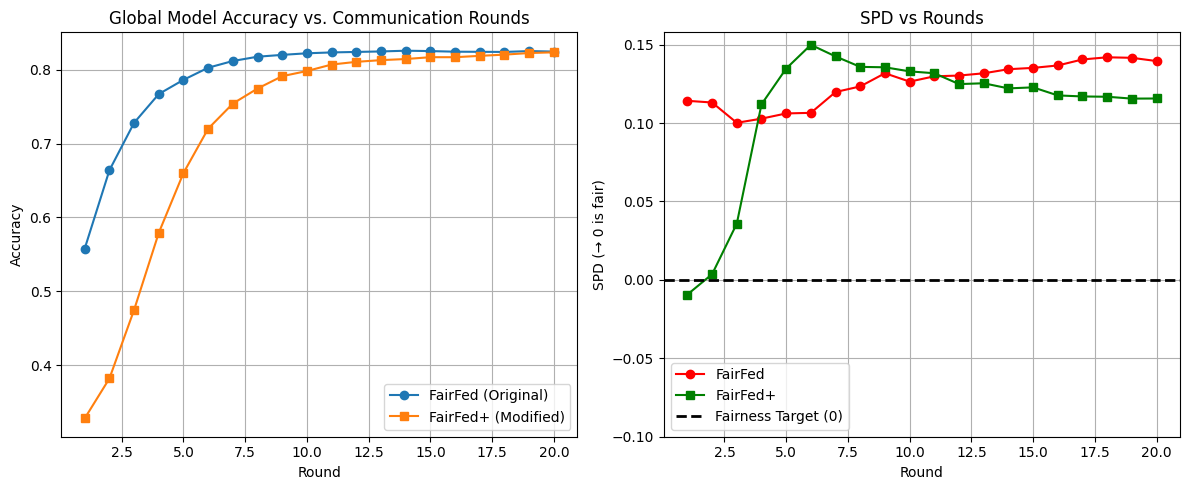

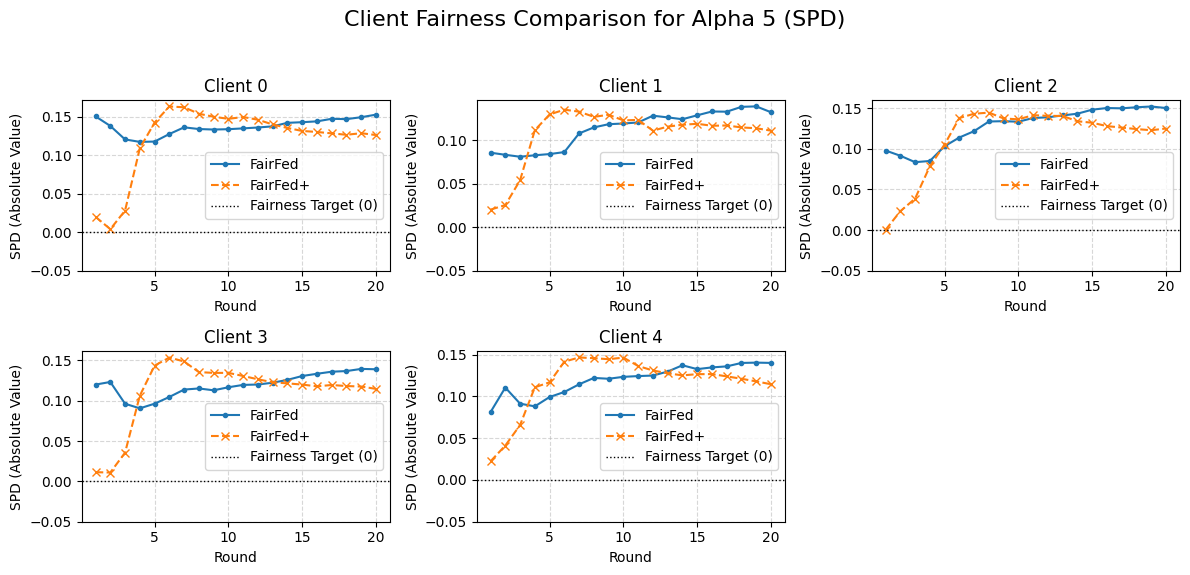


############################################################
ALPHA = 10
############################################################

--- Running FairFed (Original) ---

[FairFed] Round 1
  F_global = 5.5641
  m_k vals = [1.0255, 0.7759, 0.9251, 1.5676, 1.27]
  Deltas   = [5.553, 5.5281, 5.5073, 5.5385, 5.5056]
  Delta mean = 5.5265
Loss=0.7555 | Acc=0.2894
  [Client 0] loss trained | w_bar_new=0.2290
Loss=0.7588 | Acc=0.2873
  [Client 1] loss trained | w_bar_new=0.1548
Loss=0.7591 | Acc=0.2848
  [Client 2] loss trained | w_bar_new=0.1899
Loss=0.7603 | Acc=0.2806
  [Client 3] loss trained | w_bar_new=0.2372
Loss=0.7621 | Acc=0.2753
  [Client 4] loss trained | w_bar_new=0.1890
  Weights  = [0.229, 0.1548, 0.1899, 0.2372, 0.189]
  w_bar    = [0.229, 0.1548, 0.1899, 0.2372, 0.189]
[Round 1] Acc=0.2879 | EOD=0.0305 | SPD=-0.0318

[FairFed] Round 2
  F_global = 5.4859
  m_k vals = [1.0183, 0.7565, 0.9138, 1.5565, 1.2408]
  Deltas   = [5.4626, 5.4782, 5.4314, 5.4552, 5.4389]
  Delta mean = 

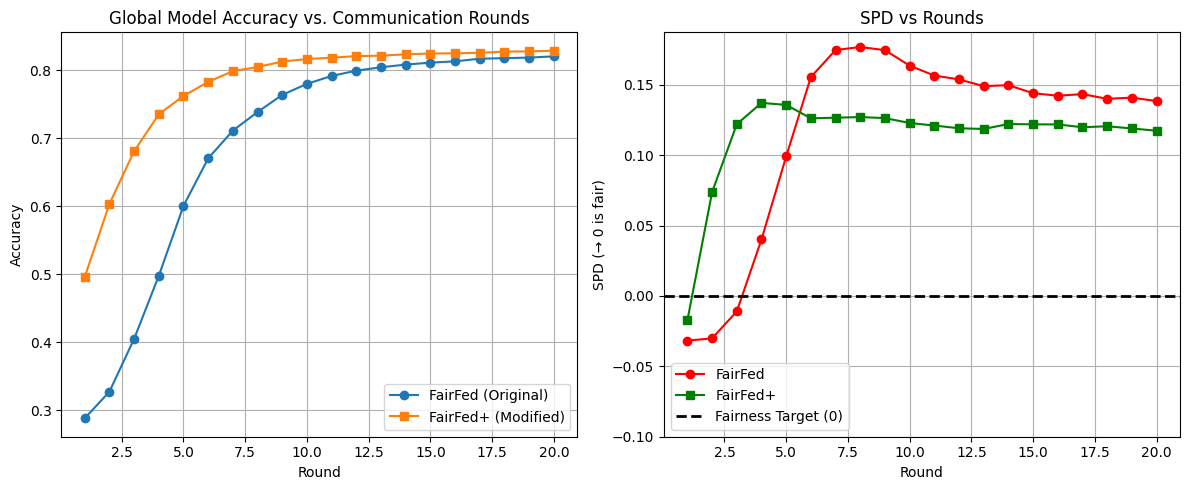

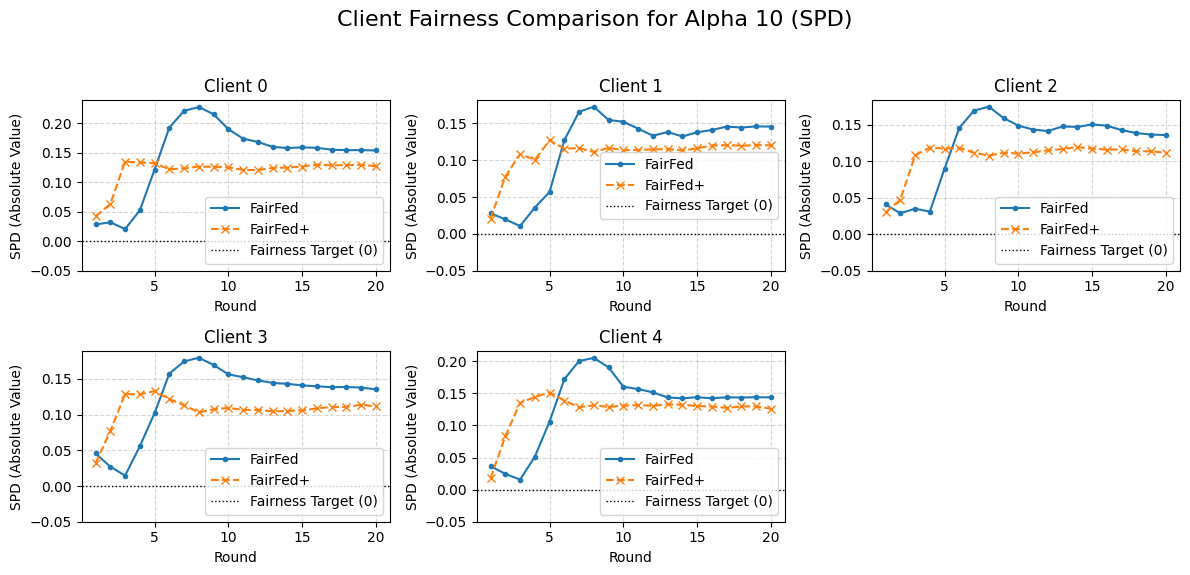

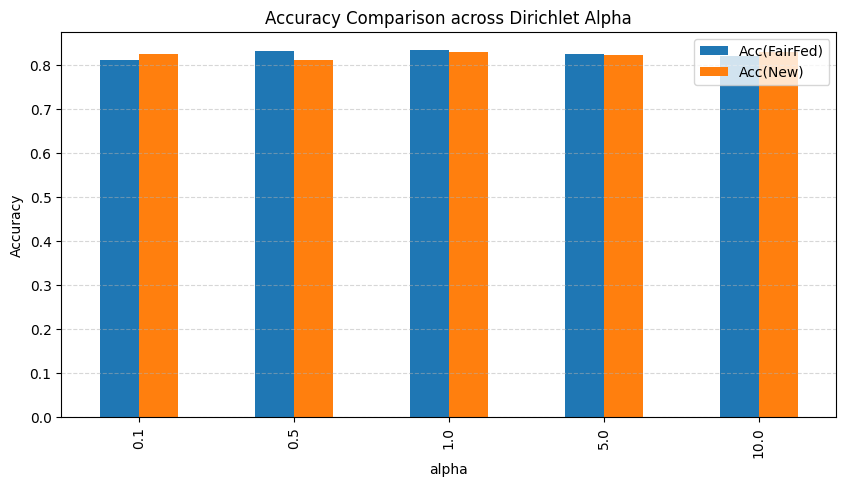

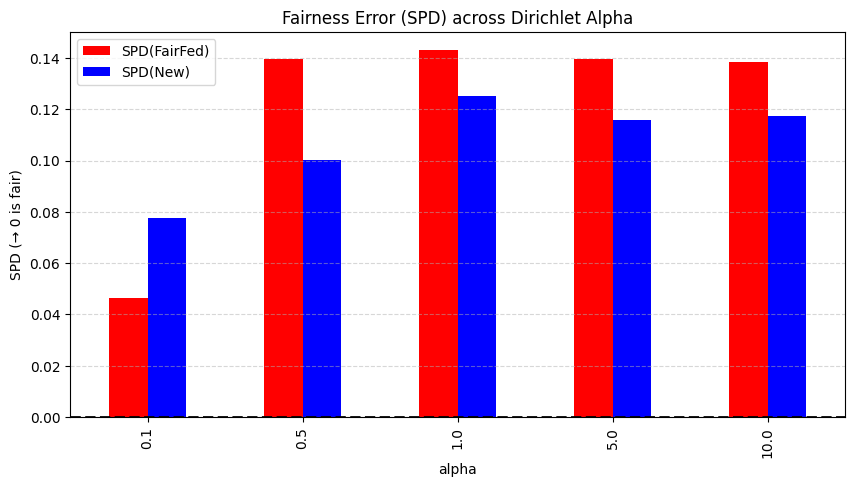


--- Client Summary Table for Alpha = 0.1 ---
 Client ID  Acc (FairFed)  EOD (FairFed)  SPD (FairFed)  Acc (FairFed+)  EOD (FairFed+)  SPD (FairFed+)
         0       0.849371       0.122434      -0.052518        0.903528        0.128226       -0.051206
         1       0.811119            NaN      -0.256376        0.789685             NaN       -0.151678
         2       0.803959            NaN      -0.241546        0.771125             NaN       -0.143961
         3       0.782536       0.260339      -0.076388        0.775440       -0.066132       -0.087199
         4       0.783333       0.210317      -0.026848        0.804167        0.126984       -0.022641

--- Client Summary Table for Alpha = 0.5 ---
 Client ID  Acc (FairFed)  EOD (FairFed)  SPD (FairFed)  Acc (FairFed+)  EOD (FairFed+)  SPD (FairFed+)
         0       0.862349       0.009141      -0.147490        0.836442        0.135345       -0.085177
         1       0.797395       0.440415      -0.154877        0.827786     

In [93]:
# =============================
# MAIN
# =============================
if __name__ == "__main__":
    run_comparison()
